#Clustering dan Pengantar Forecasting untuk Teknik Industri

Sesi ini membahas dua pendekatan analisis data yang berbeda dari pemodelan terawasi (regresi dan klasifikasi). Pertama, **clustering** merupakan metode unsupervised learning untuk mengelompokkan data berdasarkan kemiripan karakteristik tanpa label kategori sebelumnya. Kedua, **pengantar forecasting** untuk memprediksi nilai numerik berdasarkan pola waktu.

Clustering sangat relevan untuk segmentasi pelanggan, produk, mesin, atau pemasok dalam konteks teknik industri. Forecasting digunakan untuk prediksi demand, output produksi, atau lead time berdasarkan data historis.

## 1. Apa Itu Clustering?

Clustering merupakan metode unsupervised learning yang bertujuan mengelompokkan data ke dalam beberapa kelompok (cluster) berdasarkan kemiripan karakteristik. Berbeda dengan regresi dan klasifikasi yang memerlukan label target, clustering bekerja tanpa supervisor karena tujuannya adalah menemukan pola tersembunyi dalam data.

Dalam konteks teknik industri, clustering sangat relevan untuk:
- Segmentasi produk berdasarkan harga dan volume penjualan,
- Segmentasi pelanggan berdasarkan perilaku pembelian,
- Pengelompokan mesin berdasarkan karakteristik operasional,
- Segmentasi pemasok berdasarkan performa pengiriman,
- Identifikasi pola defect berdasarkan karakteristik cacat.

K-Means merupakan algoritma clustering yang paling umum digunakan karena sederhana dan efisien untuk dataset berukuran kecil hingga menengah.

## 2. Capaian Pembelajaran Sesi

Setelah menyelesaikan sesi ini, mahasiswa diharapkan mampu:
1. Menjelaskan perbedaan supervised learning dan unsupervised learning.
2. Memahami konsep dasar K-Means clustering.
3. Melakukan scaling data untuk clustering.
4. Melatih model K-Means dan menentukan jumlah cluster.
5. Menginterpretasikan hasil cluster dalam konteks operasional.
6. Mem visualisasikan hasil clustering secara efektif.
7. Memahami konsep dasar forecasting untuk data deret waktu.

## 3. Deskripsi Dataset Segmentasi Produk

Dataset merepresentasikan informasi 20 produk dengan atribut harga, volume penjualan, frekuensi pemesanan, dan jumlah klien. Variabel-variabel ini dapat digunakan untuk mengelompokkan produk ke dalam segmen yang berbeda, misalnya produk premium dengan volume rendah, produk massal dengan volume tinggi, atau produk menengah.

Segmentasi produk seperti ini relevan untuk strategi pemasaran, manajemen inventori, dan alokasi sumber daya di industri.

In [ ]:
# =============================================================================
# IMPOR LIBRARY YANG DIPERLUKAN
# =============================================================================
# pandas: manipulasi data
# matplotlib: visualisasi
# KMeans: algoritma clustering
# StandardScaler: scaling fitur untuk clustering

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print('Library untuk clustering siap digunakan')

Library untuk clustering siap digunakan


In [ ]:
# =============================================================================
# MEMBUAT DATAFRAME DARI VARIABEL PYTHON
# =============================================================================

data = {
    'Produk': [
        'P1','P2','P3','P4','P5','P6','P7','P8',
        'P9','P10','P11','P12','P13','P14','P15','P16',
        'P17','P18','P19','P20'
    ],
    'Harga_Rp': [
        50000, 120000, 80000, 200000, 60000, 150000, 90000, 180000,
        55000, 130000, 85000, 190000, 65000, 140000, 95000, 170000,
        48000, 115000, 75000, 185000
    ],
    'Volume_Penjualan': [
        500, 120, 300, 50, 400, 100, 250, 60,
        480, 130, 280, 45, 380, 110, 260, 70,
        520, 125, 320, 55
    ],
    'Frekuensi_Pemesanan': [
        20, 5, 12, 2, 18, 4, 10, 3,
        19, 6, 11, 2, 17, 5, 9, 3,
        21, 5, 13, 2
    ],
    'Jumlah_Klien': [
        30, 8, 15, 3, 25, 6, 12, 4,
        28, 9, 14, 3, 24, 7, 11, 4,
        32, 8, 16, 3
    ]
}

df = pd.DataFrame(data)
df.head()

,Produk,Harga_Rp,Volume_Penjualan,Frekuensi_Pemesanan,Jumlah_Klien
0,P1,50000,500,20,30
1,P2,120000,120,5,8
2,P3,80000,300,12,15
3,P4,200000,50,2,3
4,P5,60000,400,18,25


## 4. Seleksi Fitur untuk Clustering

Untuk clustering, kita memilih variabel numerik yang relevan dengan segmen yang ingin diidentifikasi. Pada kasus segmentasi produk, fitur yang dipilih adalah:
- `Harga_Rp`
- `Volume_Penjualan`
- `Frekuensi_Pemesanan`
- `Jumlah_Klien`

Variabel `Produk` tidak digunakan karena hanya Identifier, bukan variabel prediktif.

In [ ]:
# =============================================================================
# MEMILIH FITUR UNTUK CLUSTERING
# =============================================================================
# Hanya variabel numerik yang relevan yang digunakan

X = df[['Harga_Rp', 'Volume_Penjualan', 'Frekuensi_Pemesanan', 'Jumlah_Klien']]
X.head()

,Harga_Rp,Volume_Penjualan,Frekuensi_Pemesanan,Jumlah_Klien
0,50000,500,20,30
1,120000,120,5,8
2,80000,300,12,15
3,200000,50,2,3
4,60000,400,18,25


## 5. Scaling Data untuk Clustering

Scaling sangat penting untuk clustering karena K-Means menggunakan jarak antar titik. Jika variabel memiliki skala yang sangat berbeda (misalnya harga puluhan juta vs volume ratusan), variabel dengan skala lebih besar akan mendominasi perhitungan jarak. StandardScaler mengubah data menjadi rata-rata 0 dan simpangan baku 1.

In [ ]:
# =============================================================================
# STANDARDISASI FITUR
# =============================================================================
# StandardScaler mengubah data agar memiliki mean=0 dan std=1
# Ini memastikan semua fitur berkontribusi sama dalam perhitungan jarak

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengubah kembali ke DataFrame agar lebih mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=[col + '_Scaled' for col in X.columns])
X_scaled_df.head()

,Harga_Rp_Scaled,Volume_Penjualan_Scaled,Frekuensi_Pemesanan_Scaled,Jumlah_Klien_Scaled
0,-1.287196,1.715399,1.644751,1.795537
1,0.117383,-0.678914,-0.671800,-0.541848
2,-0.685234,0.455234,0.409257,0.201865
3,1.722615,-1.119971,-1.135110,-1.073072
4,-1.086542,1.085317,1.335877,1.264313


## 6. Menentukan Jumlah Cluster Ideal

Sebelum melatih model K-Means, kita perlu menentukan jumlah cluster (k). Metode umum yang digunakan adalah **Elbow Method**, yaitu melihat grafik inertia (varians dalam cluster) terhadap jumlah cluster. Titik "siku" pada grafik menunjukkan jumlah cluster optimal.

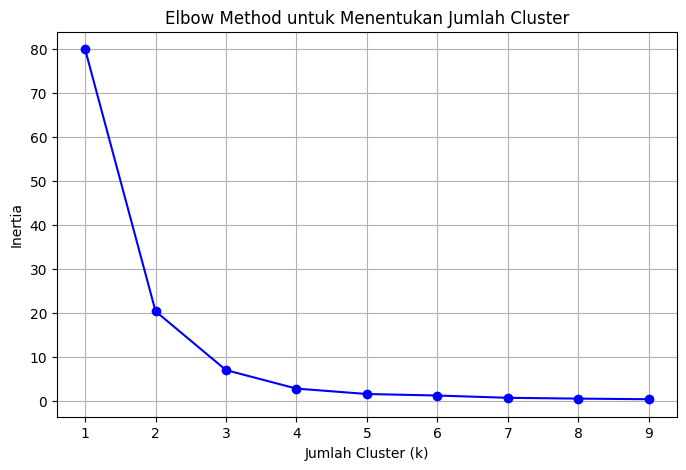

In [ ]:
# =============================================================================
# ELBOW METHOD UNTUK MENENTUKAN JUMLAH CLUSTER
# =============================================================================
# Inertia: jumlah jarak kuadrat setiap titik ke centroid cluster-nya
# Semakin banyak cluster, inertia semakin kecil
# Titik elbow menunjukkan trade-off optimal

inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xticks(K_range)
plt.grid(True)
plt.show()

## 7. Melatih Model K-Means

Berdasarkan elbow method, kita memilih jumlah cluster yang optimal. Untuk contoh ini, kita gunakan **k=3** yang merepresentasikan tiga segmen produk: misalnya premium, menengah, dan ekonomis.

In [ ]:
# =============================================================================
# INISIALISASI DAN PELATIHAN MODEL K-MEANS
# =============================================================================
# n_clusters=3: jumlah cluster yang dipilih
# random_state=42: agar hasil konsisten

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Menambahkan label cluster ke DataFrame asli
df['Cluster'] = kmeans.labels_

print('Model K-Means berhasil dilatih')
print('Jumlah cluster:', kmeans.n_clusters)
print('Centroid cluster:\n', kmeans.cluster_centers_)

Model K-Means berhasil dilatih
Jumlah cluster: 3
Centroid cluster:
 [[ 0.87986821 -0.88999115 -0.87256736 -0.80746042]
 [-1.17482973  1.43816269  1.49031417  1.56179844]
 [-0.58490669  0.34181961  0.25482056  0.0531224 ]]


## 8.Analisa Hasil Clustering

Setelah clustering selesai, langkah penting adalah menginterpretasikan karakteristik setiap cluster. Kita dapat melihat rata-rata setiap variabel per cluster untuk memahami profil segmentasi.

In [ ]:
# =============================================================================
# MENAMPILKAN JUMLAH PRODUK PER CLUSTER
# =============================================================================

cluster_count = df['Cluster'].value_counts().sort_index()
print('Jumlah produk per cluster:')
print(cluster_count)

Jumlah produk per cluster:
Cluster
0    10
1     5
2     5
Name: count, dtype: int64


## 9. Analisa Segmentasi Produk

Berdasarkan hasil clustering, kita dapat menginterpretasikan:
- **Cluster 0**: karakteristik harga, volume, frekuensi, dan jumlah klien tertentu.
- **Cluster 1**: karakteristik berbeda dari cluster 0.
- **Cluster 2**: karakteristik berbeda dari cluster 0 dan 1.

Anda dapat memberikan label pada setiap cluster berdasarkan profil, misalnya:
- Cluster berharga tinggi dan volume rendah = **Produk Premium**
- Cluster berharga menengah dan volume menengah = **Produk Standar**
- Cluster berharga rendah dan volume tinggi = **Produk Massal**

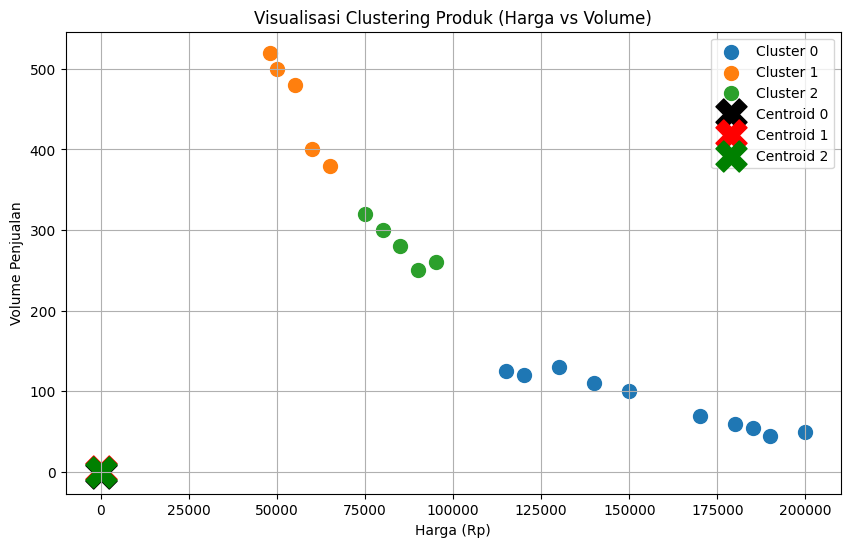

In [ ]:
# =============================================================================
# VISUALISASI CLUSTER (2D SCATTER PLOT)
# =============================================================================
# Kita visualisasi menggunakan dua fitur utama: Harga dan Volume
# Setiap cluster diberi warna berbeda

plt.figure(figsize=(10,6))

# Scatter plot untuk setiap cluster dengan warna berbeda
for cluster in [0, 1, 2]:
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Harga_Rp'], cluster_data['Volume_Penjualan'],
                label=f'Cluster {cluster}', s=100)

# Menampilkan centroid cluster
centroids = kmeans.cluster_centers_
# Konversi centroid kembali ke skala asli (untuk visualisasi 2D)
plt.scatter(centroids[0][0], centroids[0][1], marker='X', s=500, c='black', label='Centroid 0')
plt.scatter(centroids[1][0], centroids[1][1], marker='X', s=500, c='red', label='Centroid 1')
plt.scatter(centroids[2][0], centroids[2][1], marker='X', s=500, c='green', label='Centroid 2')

plt.xlabel('Harga (Rp)')
plt.ylabel('Volume Penjualan')
plt.title('Visualisasi Clustering Produk (Harga vs Volume)')
plt.legend()
plt.grid(True)
plt.show()

## 10. Aplikasi Clustering dalam Teknik Industri

Clustering K-Means telah terbukti efektif dalam berbagai aplikasi industri, termasuk:
- Segmentasi pelanggan untuk strategi pemasaran yang lebih tepat sasaran,
- Pengelompokan produk untuk manajemen inventori dan alokasi sumber daya,
- Segmentasi mesin untuk strategi maintenance yang berbeda per segmen,
- Identifikasi pola defect untuk perbaikan proses kualitas.

Keunggulan K-Means adalah sederhana, cepat, dan mudah diinterpretasikan. Namun, kelemahannya adalah perlu menentukan jumlah cluster sebelumnya dan sensitif terhadap outlier.

## 11. Pengantar Dasar Forecasting

Forecasting adalah prediksi nilai di masa depan berdasarkan pola data historis. Berbeda dengan regresi yang memprediksi berdasarkan fitur, forecasting memprediksi berdasarkan pola waktu. Contoh aplikasi dalam teknik industri:
- Prediksi demand produk,
- Prediksi output produksi,
- Prediksi lead time pemasok,
- Prediksi konsumsi energi.

Pada sesi pengantar ini, kita hanya memperkenalkan konsep dasar forecasting sederhana tanpa memasuki model yang terlalu kompleks.

In [ ]:
# =============================================================================
# CONTOH DATA DERET WAKTU UNTUK FORECASTING
# =============================================================================

forecast_data = {
    'Bulan': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'Output': [120, 135, 128, 140, 150, 145, 155, 160, 152, 165, 170, 175]
}

df_forecast = pd.DataFrame(forecast_data)
df_forecast

,Bulan,Output
0,Jan,120
1,Feb,135
2,Mar,128
3,Apr,140
4,May,150
5,Jun,145
6,Jul,155
7,Aug,160
8,Sep,152
9,Oct,165


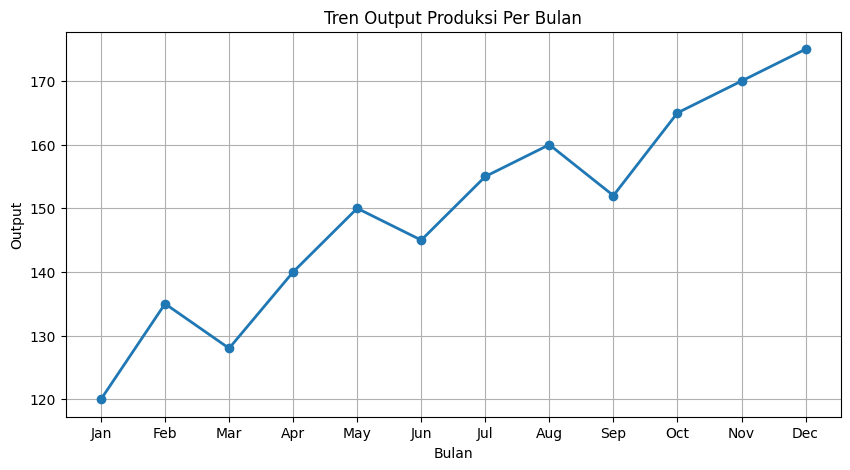

In [ ]:
# =============================================================================
# VISUALISASI DATA DERET WAKTU
# =============================================================================
# Line plot menunjukkan tren output dari waktu ke waktu

plt.figure(figsize=(10,5))
plt.plot(df_forecast['Bulan'], df_forecast['Output'], marker='o', linewidth=2)
plt.xlabel('Bulan')
plt.ylabel('Output')
plt.title('Tren Output Produksi Per Bulan')
plt.grid(True)
plt.show()

## 12. Forecasting Sederhana dengan Rata-Rata Bergerak

Salah satu metode forecasting paling sederhana adalah **Moving Average** (rata-rata bergerak). Metode ini memprediksi nilai berikutnya sebagai rata-rata dari beberapa periode terakhir. Meskipun sederhana, metode ini berguna untuk baseline forecasting.

In [ ]:
# =============================================================================
# MENGHITUNG MOVING AVERAGE (3 PERIODE)
# =============================================================================
# rolling(3).mean(): rata-rata dari 3 periode terakhir

df_forecast['Moving_Avg_3'] = df_forecast['Output'].rolling(window=3).mean()

df_forecast

,Bulan,Output,Moving_Avg_3
0,Jan,120,NaN
1,Feb,135,NaN
2,Mar,128,127.666667
3,Apr,140,134.333333
4,May,150,139.333333
5,Jun,145,145.000000
6,Jul,155,150.000000
7,Aug,160,153.333333
8,Sep,152,155.666667
9,Oct,165,159.000000


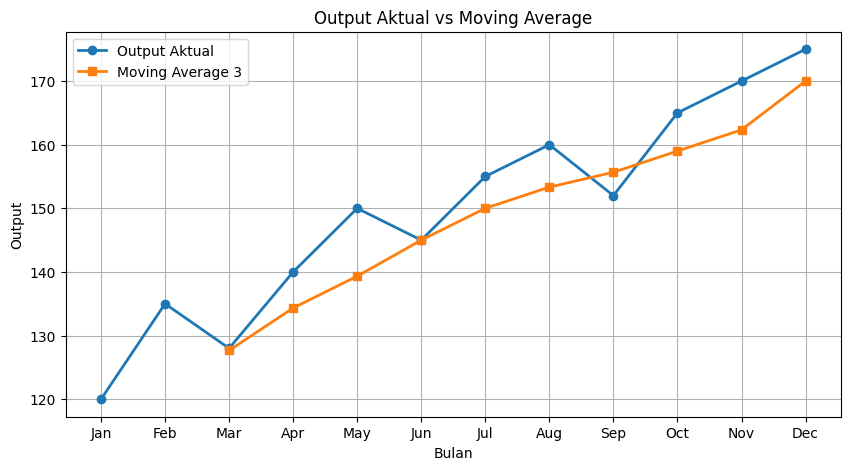

In [ ]:
# =============================================================================
# VISUALISASI DATA DAN MOVING AVERAGE
# =============================================================================

plt.figure(figsize=(10,5))
plt.plot(df_forecast['Bulan'], df_forecast['Output'], marker='o', linewidth=2, label='Output Aktual')
plt.plot(df_forecast['Bulan'], df_forecast['Moving_Avg_3'], marker='s', linewidth=2, label='Moving Average 3')
plt.xlabel('Bulan')
plt.ylabel('Output')
plt.title('Output Aktual vs Moving Average')
plt.legend()
plt.grid(True)
plt.show()

## 13. Analisa Hasil Forecasting

Moving average menunjukkan tren yang lebih halus dibanding data aktual. Hal ini karena metode ini mengurangi fluktuasi jangka pendek. Untuk forecasting yang lebih akurat, metode lain seperti Exponential Smoothing atau ARIMA dapat digunakan, tetapi untuk pengenalan awal, moving average sudah cukup untuk memahami konsep tren.

## 14. Evaluasi

Jawab singkat:
1. Apa tujuan utama clustering?
2. Mengapa perlu menentukan jumlah cluster sebelum K-Means?
3. Apa itu elbow method?
4. Mengapa scaling penting dalam clustering?
5. Apa perbedaan antara forecasting dan regresi?